In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [20]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

In [21]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model
llm=init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001D9D4938F20>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001D9D49B5F70>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

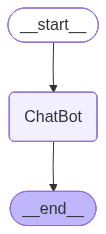

In [22]:
graph=StateGraph(State)

## node
graph.add_node("ChatBot",chatbot)
## Edges

graph.add_edge(START,"ChatBot")
graph.add_edge("ChatBot",END)


graph_builder=graph.compile()


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [24]:
response=graph_builder.invoke({"messages":"Hello My name is Geeta"})
for m in response['messages']:
    m.pretty_print()


================================ Human Message =================================

Hello My name is Geeta
================================== Ai Message ==================================

Hello Geeta, it's nice to meet you. Is there something I can help you with or would you like to chat?


In [25]:
response=graph_builder.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I don't have any information about your name. I'm a large language model, I don't have the ability to retain information about individual users or their personal details. Each time you interact with me, it's a new conversation and I don't have any prior knowledge about you.

If you'd like to share your name with me, I'd be happy to chat with you and use your name in our conversation. Alternatively, we can keep our conversation anonymous and just refer to each other as "you" or "I". How would you like to proceed?


In [26]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

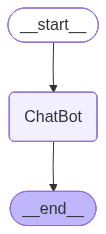

In [32]:
graph=StateGraph(State)

## node
graph.add_node("ChatBot",chatbot)
## Edges

graph.add_edge(START,"ChatBot")
graph.add_edge("ChatBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [34]:
config={"configurable":{"thread_id":"123"}}

response=graph_builder.invoke({"messages":"Hi my name is Geeta"},config=config)

response

{'messages': [HumanMessage(content='Hi my name is Geeta', additional_kwargs={}, response_metadata={}, id='6d557606-0c1c-43c3-8cb7-c749c12d7e3a'),
  AIMessage(content='Nice to meet you, Geeta. Is there something I can help you with or would you like to chat?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 41, 'total_tokens': 65, 'completion_time': 0.024673094, 'completion_tokens_details': None, 'prompt_time': 0.002530032, 'prompt_tokens_details': None, 'queue_time': 0.005598667, 'total_time': 0.027203126}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d8061-faa2-7d40-a09d-596cdddd5c56-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 24, 'total_tokens': 65})]}

In [35]:
response['messages'][-1].content

'Nice to meet you, Geeta. Is there something I can help you with or would you like to chat?'

In [36]:
response=graph_builder.invoke({"messages":"Hey what is my name"},config=config)

print(response['messages'][-1].content)

Your name is Geeta.


In [37]:
response=graph_builder.invoke({"messages":"Hey do you remember mmy name"},config=config)

print(response['messages'][-1].content)

Yes, I remember your name is Geeta.
